[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/almahova/iemocap-proj/blob/data-modelling/iemocap_modelling.ipynb)

# IEMOCAP Emotion Recognition — Modelling Pipeline
## RoBERTa Text Classification

This notebook implements a **Text-Only Transformer pipeline** for 3-class Speech Emotion Recognition (SER) on the IEMOCAP corpus.

| Component | Choice |
|-----------|--------|
| Model | `roberta-base` fine-tuned for sequence classification |
| Split | Sessions 1–4 train · 10 % of train as val · Session 5 test (speaker-independent) |
| Loss | Weighted Cross-Entropy (compensates ~55 % Negative imbalance) |
| Primary metric | **Macro F1-Score** |
| Classes | `Negative` (0) · `Positive` (1) · `Neutral` (2) |

## Implementation Guidelines

Using a pre-trained RoBERTa model to classify transcription text into 3 emotion groups:
**Neutral**, **Positive**, and **Negative**.

- Split: **Sessions 1–4 train / 10 % of train as validation / Session 5 held-out test** (speaker-independent)
- Address class imbalance with **inverse-frequency class weights** in the loss function
- Report **confusion matrix**, **accuracy**, and **Macro F1-Score**
- Use **early stopping** to prevent overfitting (patience = 3 epochs on val Macro F1)

---
## 1. Configuration & Imports

In [1]:
# ── All hyperparameters in one place — change here, nowhere else ──────────────
CONFIG = {
    "model_name":          "roberta-base",
    "text_column":         "transcription",
    "max_length":          128,
    "batch_size":          32,
    "lr":                  2e-5,
    "weight_decay":        0.01,
    "epochs":              10,
    "early_stop_patience": 3,
    "test_session":        5,      # session held out as test set — matches audio/fusion setup
    "val_ratio":           0.10,   # fraction of Ses01-04 used for validation
    "random_seed":         42,
    "num_labels":          3,
}

LABEL2ID = {"Negative": 0, "Positive": 1, "Neutral": 2}
ID2LABEL  = {v: k for k, v in LABEL2ID.items()}

EMOTION_GROUP_MAP = {
    "happy":      "Positive",
    "excited":    "Positive",
    "angry":      "Negative",
    "frustrated": "Negative",
    "fear":       "Negative",
    "sad":        "Negative",
    "disgust":    "Negative",
    "other":      "Neutral",
    "neutral":    "Neutral",
    "surprise":   "Neutral",
}

import os
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from torch.utils.data import Dataset, DataLoader
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    f1_score, accuracy_score,
    confusion_matrix, classification_report,
)
from tqdm import tqdm

torch.manual_seed(CONFIG["random_seed"])
np.random.seed(CONFIG["random_seed"])

# ── Device — CUDA > MPS (Apple Silicon) > CPU ────────────────────────────────
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Device : {device}")
print(f"PyTorch: {torch.__version__}")

# ── Checkpoint directory — Google Drive in Colab, ~/Downloads locally ─────────
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    CHECKPOINT_DIR = "/content/drive/MyDrive"
else:
    CHECKPOINT_DIR = os.path.expanduser("~/Downloads")

Device : mps
PyTorch: 2.12.0


---
## 2. Data Loading & Preprocessing

In [2]:
from datasets import load_dataset


def load_and_preprocess(
    emotion_map: dict,
    label2id: dict,
    text_col: str,
) -> pd.DataFrame:
    """Load IEMOCAP from HuggingFace, group emotions, encode labels, drop unknowns.

    Returns a DataFrame with columns: text_col, emotion_group, label, session_num.
    """
    ds = load_dataset("AbstractTTS/IEMOCAP")
    df = ds["train"].to_pandas()

    df["emotion_group"] = df["major_emotion"].map(emotion_map)
    df = df.dropna(subset=["emotion_group", text_col]).reset_index(drop=True)
    df["label"] = df["emotion_group"].map(label2id)
    df["session_num"] = df["file"].str.extract(r"Ses(\d{2})").astype(int)

    print(f"Total samples after cleaning: {len(df)}")
    print(df["emotion_group"].value_counts().to_string())
    return df


def loso_split(
    df: pd.DataFrame,
    test_session: int,
    val_ratio: float,
    seed: int,
) -> tuple:
    """Hold out test_session as test; split the remaining sessions into train/val.

    Returns: (train_df, val_df, test_df)
    """
    test_df     = df[df["session_num"] == test_session].reset_index(drop=True)
    trainval_df = df[df["session_num"] != test_session].reset_index(drop=True)

    train_df, val_df = train_test_split(
        trainval_df,
        test_size=val_ratio,
        stratify=trainval_df["label"],
        random_state=seed,
    )

    for name, part in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
        counts = " | ".join(
            f"{k}: {v}" for k, v in part["emotion_group"].value_counts().items()
        )
        print(f"{name:5s}: {len(part):5d} rows | {counts}")

    return (
        train_df.reset_index(drop=True),
        val_df.reset_index(drop=True),
        test_df.reset_index(drop=True),
    )


df = load_and_preprocess(EMOTION_GROUP_MAP, LABEL2ID, CONFIG["text_column"])
train_df, val_df, test_df = loso_split(
    df, CONFIG["test_session"], CONFIG["val_ratio"], CONFIG["random_seed"]
)


Total samples after cleaning: 10039
emotion_group
Negative    5545
Positive    2632
Neutral     1862
Train:  7082 rows | Negative: 3956 | Positive: 1817 | Neutral: 1309
Val  :   787 rows | Negative: 440 | Positive: 202 | Neutral: 145
Test :  2170 rows | Negative: 1149 | Positive: 613 | Neutral: 408


---
## 3. Dataset & DataLoaders

In [3]:
class IEMOCAPTextDataset(Dataset):
    """PyTorch Dataset that tokenises transcription text for RoBERTa fine-tuning."""

    def __init__(
        self,
        texts: list,
        labels: list,
        tokenizer,
        max_length: int,
    ):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding="max_length",
            max_length=max_length,
            return_tensors="pt",
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int) -> dict:
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels":         self.labels[idx],
        }


def build_dataloaders(
    train_df: pd.DataFrame,
    val_df:   pd.DataFrame,
    test_df:  pd.DataFrame,
    tokenizer,
    config:   dict,
) -> tuple:
    """Tokenise each split and wrap in DataLoaders.

    Returns: (train_loader, val_loader, test_loader)
    """
    text_col   = config["text_column"]
    max_length = config["max_length"]
    batch_size = config["batch_size"]

    train_ds = IEMOCAPTextDataset(
        train_df[text_col].tolist(), train_df["label"].tolist(), tokenizer, max_length
    )
    val_ds = IEMOCAPTextDataset(
        val_df[text_col].tolist(), val_df["label"].tolist(), tokenizer, max_length
    )
    test_ds = IEMOCAPTextDataset(
        test_df[text_col].tolist(), test_df["label"].tolist(), tokenizer, max_length
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader


tokenizer = RobertaTokenizer.from_pretrained(CONFIG["model_name"])
train_loader, val_loader, test_loader = build_dataloaders(
    train_df, val_df, test_df, tokenizer, CONFIG
)
print(f"Batches — train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Batches — train: 222 | val: 25 | test: 68


---
## 4. Model, Class Weights & Optimiser

In [4]:
def compute_weights(train_labels: list, num_labels: int) -> torch.Tensor:
    """Compute inverse-frequency class weights from the training set labels."""
    classes = np.arange(num_labels)
    weights = compute_class_weight("balanced", classes=classes, y=train_labels)
    return torch.tensor(weights, dtype=torch.float)


def build_model(config: dict, id2label: dict, label2id: dict):
    """Load roberta-base with a 3-class sequence classification head."""
    model = RobertaForSequenceClassification.from_pretrained(
        config["model_name"],
        num_labels=config["num_labels"],
        id2label=id2label,
        label2id=label2id,
    )
    return model.to(device)


class_weights = compute_weights(
    train_df["label"].tolist(), CONFIG["num_labels"]
).to(device)
print(
    "Class weights:",
    {ID2LABEL[i]: f"{w:.3f}" for i, w in enumerate(class_weights.cpu().tolist())},
)

model     = build_model(CONFIG, ID2LABEL, LABEL2ID)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"]
)

total_steps = len(train_loader) * CONFIG["epochs"]
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps,
)
print(f"Total optimisation steps: {total_steps}")

Class weights: {'Negative': '0.597', 'Positive': '1.299', 'Neutral': '1.803'}


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total optimisation steps: 2220


---
## 5. Training Loop with Early Stopping

In [5]:
def train_epoch(
    model,
    loader: DataLoader,
    optimizer,
    scheduler,
    criterion: nn.Module,
    device: torch.device,
) -> float:
    """Run one training epoch. Returns mean cross-entropy loss over all batches."""
    model.train()
    total_loss = 0.0

    for batch in tqdm(loader, desc="  train", leave=False):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        optimizer.zero_grad()
        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
        loss   = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(
    model,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
) -> dict:
    """Evaluate model on a DataLoader. Returns dict with loss, accuracy, macro_f1."""
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["labels"].to(device)

            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
            total_loss += criterion(logits, labels).item()
            all_preds.extend(logits.argmax(dim=-1).cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    return {
        "loss":     total_loss / len(loader),
        "accuracy": accuracy_score(all_labels, all_preds),
        "macro_f1": f1_score(all_labels, all_preds, average="macro"),
    }


def fit(
    model,
    train_loader: DataLoader,
    val_loader:   DataLoader,
    optimizer,
    scheduler,
    criterion:    nn.Module,
    config:       dict,
    device:       torch.device,
) -> dict:
    """Full training loop with early stopping on val Macro F1.

    Restores the best checkpoint at the end.
    Returns history dict with per-epoch train/val loss and F1.
    """
    best_f1, patience_count = 0.0, 0
    best_state = None
    history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}

    for epoch in range(1, config["epochs"] + 1):
        train_loss    = train_epoch(model, train_loader, optimizer, scheduler, criterion, device)
        train_metrics = evaluate(model, train_loader, criterion, device)
        val_metrics   = evaluate(model, val_loader,   criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["train_f1"].append(train_metrics["macro_f1"])
        history["val_f1"].append(val_metrics["macro_f1"])

        print(
            f"Epoch {epoch:02d}/{config['epochs']} | "
            f"train loss {train_loss:.4f} | "
            f"val loss {val_metrics['loss']:.4f} | "
            f"val acc {val_metrics['accuracy']:.4f} | "
            f"val F1 {val_metrics['macro_f1']:.4f}"
        )

        if val_metrics["macro_f1"] > best_f1:
            best_f1        = val_metrics["macro_f1"]
            best_state     = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= config["early_stop_patience"]:
                print(
                    f"Early stopping at epoch {epoch} "
                    f"(no improvement for {config['early_stop_patience']} epochs)"
                )
                break

    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    print(f"\nBest val Macro F1: {best_f1:.4f} — best checkpoint restored.")
    return history

---
## 6. Run Training

In [6]:
history = fit(
    model, train_loader, val_loader,
    optimizer, scheduler, criterion,
    CONFIG, device,
)

  train:   0%|          | 0/222 [00:00<?, ?it/s]

  train:   0%|          | 1/222 [00:06<25:35,  6.95s/it]

  train:   1%|          | 2/222 [00:09<15:58,  4.36s/it]

  train:   1%|▏         | 3/222 [00:11<12:37,  3.46s/it]

  train:   2%|▏         | 4/222 [00:14<11:03,  3.04s/it]

...

  train:  99%|█████████▉| 220/222 [08:32<00:04,  2.31s/it]

  train: 100%|█████████▉| 221/222 [08:35<00:02,  2.31s/it]

  train: 100%|██████████| 222/222 [08:36<00:00,  1.97s/it]

Epoch 07/10 | train loss 0.3699 | val loss 1.0090 | val acc 0.7281 | val F1 0.6756
Early stopping at epoch 7 (no improvement for 3 epochs)



Best val Macro F1: 0.6757 — best checkpoint restored.


### Save Model Weights

To save the trained model's weights, we can use `torch.save()` to store the `state_dict()` of the model. This will create a `.pth` file containing the learned parameters.

In [7]:
model_save_path = "./best_model_weights.pth"
try:
    torch.save(model.state_dict(), model_save_path)
    print(f"Model weights saved to {model_save_path}")
except NameError:
    print("Error: 'model' or 'torch' not defined. Please ensure previous cells have been run.")

Model weights saved to ./best_model_weights.pth


### Load the Model and Make Predictions

After saving the model weights, you can load the model back into memory and use it for inference on new data. This involves:
1. Re-initializing the model with the same architecture.
2. Loading the saved `state_dict` into the model.
3. Tokenizing a new input text.
4. Passing the tokenized input through the model to get predictions.

In [8]:
# Re-initialize the model with the same architecture
try:
    loaded_model = build_model(CONFIG, ID2LABEL, LABEL2ID)

    # Load the saved state dictionary
    loaded_model.load_state_dict(torch.load(model_save_path))
    loaded_model.to(device)
    loaded_model.eval() # Set the model to evaluation mode

    print("Model loaded successfully!")
except NameError:
    print("Error: 'build_model', 'CONFIG', 'ID2LABEL', 'LABEL2ID', 'device', or 'torch' not defined. Ensure previous cells are run.")
except FileNotFoundError:
    print(f"Error: Model weights not found at {model_save_path}. Please ensure the saving cell was executed.")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully!


In [9]:
def predict_emotion(text: str, model, tokenizer, device, id2label: dict, max_length: int = 128):
    """Predicts the emotion of a given text using the loaded model."""
    # Tokenize the input text
    inputs = tokenizer(
        text,
        truncation=True,
        padding='max_length',
        max_length=max_length,
        return_tensors='pt'
    )

    # Move inputs to the correct device
    input_ids = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

    # Get the predicted label ID and map it back to the emotion name
    predicted_label_id = torch.argmax(logits, dim=-1).item()
    predicted_emotion = id2label[predicted_label_id]

    return predicted_emotion

# Example usage:
try:
    new_text = "I am so happy to hear that!"
    predicted_emotion = predict_emotion(new_text, loaded_model, tokenizer, device, ID2LABEL, CONFIG['max_length'])
    print(f"Text: '{new_text}'\nPredicted Emotion: {predicted_emotion}")

    new_text_2 = "This is absolutely infuriating."
    predicted_emotion_2 = predict_emotion(new_text_2, loaded_model, tokenizer, device, ID2LABEL, CONFIG['max_length'])
    print(f"\nText: '{new_text_2}'\nPredicted Emotion: {predicted_emotion_2}")

    new_text_3 = "I am going to the store now."
    predicted_emotion_3 = predict_emotion(new_text_3, loaded_model, tokenizer, device, ID2LABEL, CONFIG['max_length'])
    print(f"\nText: '{new_text_3}'\nPredicted Emotion: {predicted_emotion_3}")
except NameError:
    print("Error: 'loaded_model', 'tokenizer', 'device', 'ID2LABEL', or 'CONFIG' not defined. Ensure model loading cell was executed.")

Text: 'I am so happy to hear that!'
Predicted Emotion: Positive

Text: 'This is absolutely infuriating.'
Predicted Emotion: Negative

Text: 'I am going to the store now.'
Predicted Emotion: Negative


### Save Model Weights

To save the trained model's weights, we can use `torch.save()` to store the `state_dict()` of the model. This will create a `.pth` file containing the learned parameters.

In [10]:
model_save_path = "./best_model_weights.pth"
torch.save(model.state_dict(), model_save_path)
print(f"Model weights saved to {model_save_path}")

Model weights saved to ./best_model_weights.pth


In [11]:
model_save_path_pt = os.path.join(CHECKPOINT_DIR, "text_best_model_weights.pt")
torch.save(model.state_dict(), model_save_path_pt)
print(f"Model weights saved to {model_save_path_pt}")

Model weights saved to /Users/freediver/Downloads/text_best_model_weights.pt


---
## 7. Final Evaluation on Test Set

Test Accuracy : 0.6793
Test Macro F1 : 0.6519
              precision    recall  f1-score   support

    Negative       0.86      0.68      0.76      1149
    Positive       0.72      0.71      0.71       613
     Neutral       0.39      0.62      0.48       408

    accuracy                           0.68      2170
   macro avg       0.66      0.67      0.65      2170
weighted avg       0.73      0.68      0.69      2170



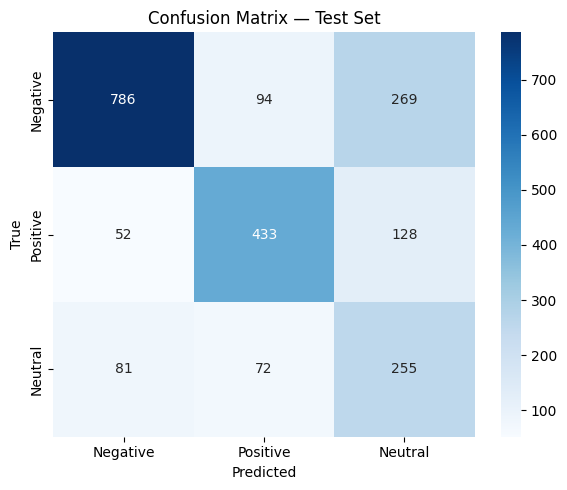

In [12]:
def plot_confusion_matrix(cm: np.ndarray, class_names: list) -> None:
    """Display a labelled confusion matrix heatmap."""
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names,
        ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title("Confusion Matrix — Test Set")
    plt.tight_layout()
    plt.show()


def report_metrics(
    model,
    test_loader: DataLoader,
    device: torch.device,
    id2label: dict,
) -> None:
    """Print full classification report and confusion matrix for the test set."""
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in test_loader:
            logits = model(
                input_ids=batch["input_ids"].to(device),
                attention_mask=batch["attention_mask"].to(device),
            ).logits
            all_preds.extend(logits.argmax(dim=-1).cpu().tolist())
            all_labels.extend(batch["labels"].tolist())

    class_names = [id2label[i] for i in sorted(id2label)]

    print("=" * 50)
    print(f"Test Accuracy : {accuracy_score(all_labels, all_preds):.4f}")
    print(f"Test Macro F1 : {f1_score(all_labels, all_preds, average='macro'):.4f}")
    print("=" * 50)
    print(classification_report(all_labels, all_preds, target_names=class_names))

    cm = confusion_matrix(all_labels, all_preds)
    plot_confusion_matrix(cm, class_names)


report_metrics(model, test_loader, device, ID2LABEL)

---
## 8. Training Curves

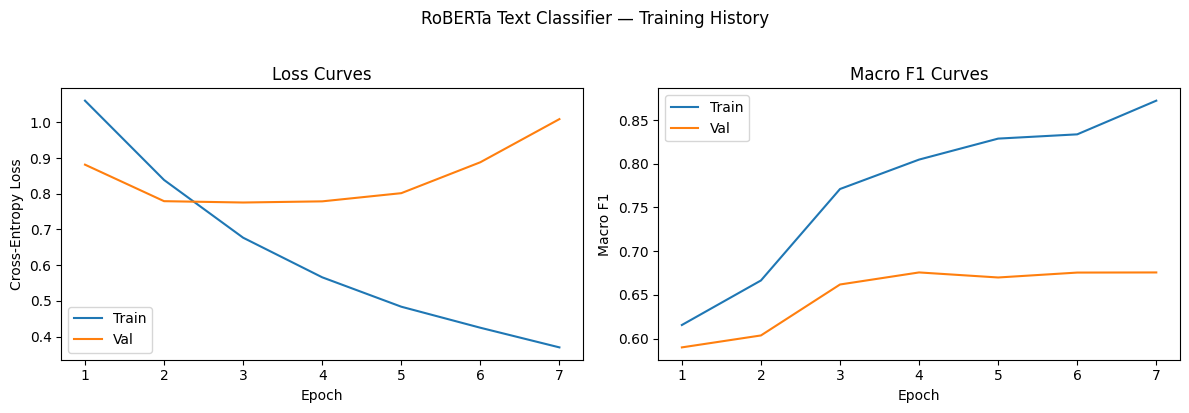

In [13]:
def plot_training_curves(history: dict) -> None:
    """Plot train/val loss and Macro F1 over epochs side by side."""
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, history["train_loss"], label="Train")
    ax1.plot(epochs, history["val_loss"],   label="Val")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Cross-Entropy Loss")
    ax1.set_title("Loss Curves")
    ax1.legend()

    ax2.plot(epochs, history["train_f1"], label="Train")
    ax2.plot(epochs, history["val_f1"],   label="Val")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Macro F1")
    ax2.set_title("Macro F1 Curves")
    ax2.legend()

    plt.suptitle("RoBERTa Text Classifier — Training History", y=1.02)
    plt.tight_layout()
    plt.show()


plot_training_curves(history)